<a href="https://colab.research.google.com/github/YenugulaRamya/my-colab-projects/blob/main/basic_quantum_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
import qiskit
import qiskit_aer
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

In [ ]:
print(f"Qiskit version: {qiskit.__version__}")
print(f"Qiskit aer version: {qiskit_aer.__version__}")
print("Using AerSimulator for both statevector and shot-based workflows")

Qiskit version: 2.3.1
Qiskit aer version: 0.17.2
Using AerSimulator for both statevector and shot-based workflows


In [ ]:
bell_circuit=QuantumCircuit(2,2)
bell_circuit.h(0)
bell_circuit.cx(0,1)
bell_circuit.barrier(label='Entangle')
bell_circuit.measure([0,1],[0,1])
print(bell_circuit.draw(output='text'))


     ┌───┐      Entangle ┌─┐   
q_0: ┤ H ├──■──────░─────┤M├───
     └───┘┌─┴─┐    ░     └╥┘┌─┐
q_1: ─────┤ X ├────░──────╫─┤M├
          └───┘    ░      ║ └╥┘
c: 2/═════════════════════╩══╩═
                          0  1 


In [ ]:
def exact_probabilities_from_statevector(measured_circuit: QuantumCircuit) -> dict:
    """Return exact computational-basis probabilities from a measured circuit."""

    statevector_backend = AerSimulator(method='statevector')
    statevector_circuit = measured_circuit.remove_final_measurements(inplace=False)
    statevector_circuit.save_statevector()

    transpiled = transpile(statevector_circuit, statevector_backend)
    result = statevector_backend.run(transpiled).result()
    statevector = np.asarray(result.get_statevector(transpiled))

    print("Exact statevector:", statevector)

    n_qubits = statevector_circuit.num_qubits
    probabilities = {}

    for basis_index, amplitude in enumerate(statevector):
        bitstring = format(basis_index, f'0{n_qubits}b')
        probabilities[bitstring] = float(np.abs(amplitude) ** 2)

    return probabilities


exact_probs = exact_probabilities_from_statevector(bell_circuit)

print("Exact probabilities from statevector:")
for bitstring in sorted(exact_probs):
    print(f"  P({bitstring}) = {exact_probs[bitstring]:.6f}")

Exact statevector: [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
Exact probabilities from statevector:
  P(00) = 0.500000
  P(01) = 0.000000
  P(10) = 0.000000
  P(11) = 0.500000


In [ ]:
def shot_based_probabilities(measured_circuit: QuantumCircuit, shots: int) -> dict:
    """Estimate probabilities from counts using a shot-based Aer simulator."""

    shot_backend = AerSimulator()
    transpiled = transpile(measured_circuit, shot_backend)
    result = shot_backend.run(transpiled, shots=shots).result()
    counts = result.get_counts(transpiled)

    probabilities = {
        bitstring: counts.get(bitstring, 0) / shots
        for bitstring in ['00', '01', '10', '11']
    }

    return probabilities


shot_values = [128, 512, 2048, 10000]
estimated_p00 = []
estimated_p11 = []

for n_shots in shot_values:
    probs = shot_based_probabilities(bell_circuit, n_shots)
    estimated_p00.append(probs['00'])
    estimated_p11.append(probs['11'])

    print(
        f"shots={n_shots:5d} -> "
        f"P(00)={probs['00']:.4f}, "
        f"P(11)={probs['11']:.4f}, "
        f"P(01)+P(10)={probs['01'] + probs['10']:.4f}"
    )

shots=  128 -> P(00)=0.4453, P(11)=0.5547, P(01)+P(10)=0.0000
shots=  512 -> P(00)=0.4844, P(11)=0.5156, P(01)+P(10)=0.0000
shots= 2048 -> P(00)=0.4946, P(11)=0.5054, P(01)+P(10)=0.0000
shots=10000 -> P(00)=0.5054, P(11)=0.4946, P(01)+P(10)=0.0000


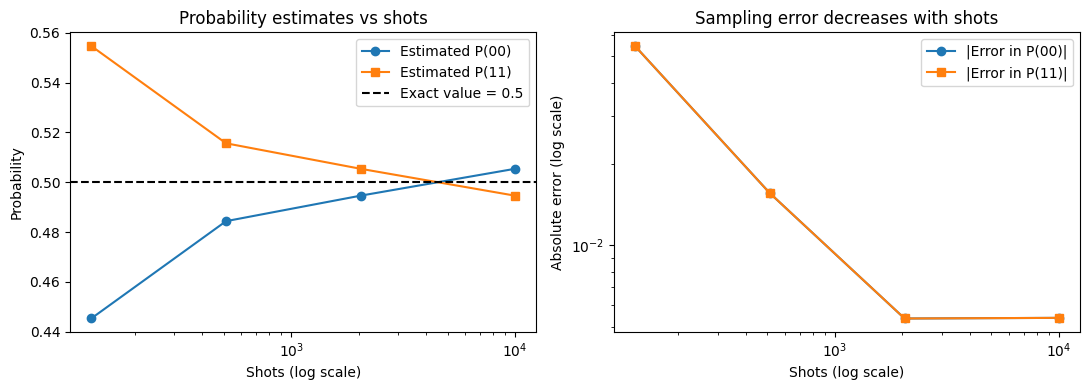


Absolute errors:
 shots=  128: |P00-0.5|=0.05469, |P11-0.5|=0.05469
 shots=  512: |P00-0.5|=0.01563, |P11-0.5|=0.01563
 shots= 2048: |P00-0.5|=0.00537, |P11-0.5|=0.00537
 shots=10000: |P00-0.5|=0.00540, |P11-0.5|=0.00540


In [ ]:
# Verification: convergence to exact probabilities

target_p00 = exact_probs.get('00', 0.0)
target_p11 = exact_probs.get('11', 0.0)

error_p00 = [abs(p - target_p00) for p in estimated_p00]
error_p11 = [abs(p - target_p11) for p in estimated_p11]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Plot estimated probabilities
axes[0].plot(shot_values, estimated_p00, marker='o', label='Estimated P(00)')
axes[0].plot(shot_values, estimated_p11, marker='s', label='Estimated P(11)')
axes[0].axhline(target_p00, linestyle='--', color='black', label='Exact value = 0.5')
axes[0].set_xscale('log')
axes[0].set_xlabel('Shots (log scale)')
axes[0].set_ylabel('Probability')
axes[0].set_title('Probability estimates vs shots')
axes[0].legend()

# Plot errors
axes[1].plot(shot_values, error_p00, marker='o', label='|Error in P(00)|')
axes[1].plot(shot_values, error_p11, marker='s', label='|Error in P(11)|')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Shots (log scale)')
axes[1].set_ylabel('Absolute error (log scale)')
axes[1].set_title('Sampling error decreases with shots')
axes[1].legend()

plt.tight_layout()
plt.show()
print("\nAbsolute errors:")
for n_shots, e00, e11 in zip(shot_values, error_p00, error_p11):
    print(f" shots={n_shots:5d}: |P00-0.5|={e00:.5f}, |P11-0.5|={e11:.5f}")